In [1]:
import copy
import getopt
import math
import networkx as nx
import matplotlib.pyplot as plt
import operator
import os
import random
import sys
from scipy import stats
import seaborn as sns
import time
%matplotlib inline  

In [6]:
def clean(series):
    series = series.str.upper()
    series = series.str.replace(u"Á", "A")
    series = series.str.replace(u"É", "E")
    series = series.str.replace(u"Ú", "U")
    series = series.str.replace(u"Ó", "O")
    series = series.str.replace(u"Í", "I")
    series = series.str.replace(u"Ã", "A")
    series = series.str.replace(u"Õ", "O")
    series = series.str.replace(u"Ô", "O")
    series = series.str.replace(u"Â", "A")
    series = series.str.replace(u"Ê", "E")
    series = series.str.replace(u"Ç", "C")
    series = series.str.replace(u"-", "")
    series = series.str.replace(u"'", "")
    series = series.str.upper()
    return series

def clean_str(series):
    series = series.upper()
    series = series.replace(u"Á", "A")
    series = series.replace(u"É", "E")
    series = series.replace(u"Ú", "U")
    series = series.replace(u"Ó", "O")
    series = series.replace(u"Í", "I")
    series = series.replace(u"Ã", "A")
    series = series.replace(u"Õ", "O")
    series = series.replace(u"Ô", "O")
    series = series.replace(u"Â", "A")
    series = series.replace(u"Ê", "E")
    series = series.replace(u"Ç", "C")
    series = series.replace(u"-", "")
    series = series.replace(u"'", "")
    return series

In [2]:
def create_network(path):
    """
    Create a NetworkX graph object using the airport and route databases.
    Args:
        nodes: The file path to the nodes .csv file.
        edeges: The file path to the edges .csv file.
    Returns:
        G: A NetworkX DiGraph object populated with the nodes and edges assigned
           by the data files from the arguments.
           
   
    """
    print("Creating network.")
    G = nx.read_gexf(path)
    
    # Add pos attribute in nodes
    for node in G.nodes():
        long = G.nodes[node]['long']
        lat = G.nodes[node]['lat']
        loc = (long, lat)
        node_dict = {node : loc}
        nx.set_node_attributes(G, node_dict, 'pos')
    
    # Calculate the edge weights
    print("\tCalculating edge weights",end="")
    degree_network = nx.Graph(G)
    ldegree = degree_network.degree
    for i,j in G.edges():
        degree_sum = ldegree[i] + ldegree[j]
        G[i][j]['weight'] = degree_sum
    
    print("\t\t\t\t[Done]")
    
    G = nx.relabel_nodes(G, clean_str)
    
    # Calculate the edge distances
    print("\tCalculating edge distance",end="")
    G = calculate_distance(G)
    print("\t\t\t\t[Done]")

    
    # Add clustering data
    print("\tCalculating clustering coefficents",end="")
    cluster_network = nx.Graph(G)
    lcluster = nx.clustering(cluster_network)
    for i,j in G.edges():
        cluster_sum = lcluster[i] + lcluster[j]
        G[i][j]['cluster'] = cluster_sum
    print("\t\t\t[Done]")
    
    return G

In [3]:
from math import cos, asin, sqrt, pi

def distance(lat1, lon1, lat2, lon2):
    p = pi/180
    a = 0.5 - cos((lat2-lat1)*p)/2 + cos(lat1*p) * cos(lat2*p) * (1-cos((lon2-lon1)*p))/2
    return 12742 * asin(sqrt(a))

def calculate_distance(input_network):
    """
    Add weights to the edges of a network based on the degrees of the connecting
    verticies, and return the network.
    Args:
        input_network: A NetworkX graph object
    Returns:
        G: A weighted NetworkX graph object.
    """
    
    G = input_network.copy()

    # Add weights to edges
    for node, successor in G.edges():
        dist = distance(G.nodes[node]['lat'], G.nodes[node]['long'],
                        G.nodes[successor]['lat'], G.nodes[successor]['long'])
        edge_dict = {(node,successor): dist}
        nx.set_edge_attributes(G, edge_dict, 'distance')
    return G

In [4]:
def calculate_weights(input_network):
    """
    Add weights to the edges of a network based on the degrees of the connecting
    verticies, and return the network.
    Args:
        input_network: A NetworkX graph object
    Returns:
        G: A weighted NetworkX graph object.
    """
    
    G = input_network.copy()

    # Add weights to edges
    for node in G.nodes():
        successors = G.neighbors(node)
        weights = {}

        # Calculate the total out degree of all succs
        total_degree = 0
        for successor in successors: 
            weights[successor] = G.degree(successor)
            
        largest_weight = max(weights.items())[1]
        smallest_weight = min(weights.items())[1]
        
        successors = G.neighbors(node)
        for successor in successors:
            if largest_weight == smallest_weight:
                relative_weight = 0
            else: 
                relative_weight = (weights[successor] - smallest_weight) / (largest_weight - smallest_weight)    
            G[node][successor]['weight'] = relative_weight

    return G


In [7]:
G = create_network('grafo_cidades_aeroportos.gexf')
H = create_network('grafo_cidades.gexf')

Creating network.
	Calculating edge weights				[Done]
	Calculating edge distance				[Done]
	Calculating clustering coefficents			[Done]
Creating network.
	Calculating edge weights				[Done]
	Calculating edge distance				[Done]
	Calculating clustering coefficents			[Done]


In [8]:
print(nx.info(G))
print(nx.info(H))

Name: 
Type: Graph
Number of nodes: 5569
Number of edges: 17504
Average degree:   6.2862
Name: 
Type: Graph
Number of nodes: 5568
Number of edges: 16470
Average degree:   5.9159


In [9]:
print('Network G Average Shortest path Length', nx.average_shortest_path_length(G))
print('Network H Average Shortest path Length', nx.average_shortest_path_length(H))

Network G Average Shortest path Length 7.233737071803477
Network H Average Shortest path Length 27.256326794389764


In [10]:
print("Network G Diameter", nx.diameter(G))
print("Network H Diameter", nx.diameter(H))

Network G Diameter 16
Network H Diameter 78


In [11]:
print("Network G Density", nx.density(G))
print("Network H Density", nx.density(H))

Network G Density 0.0011289919773458574
Network H Density 0.0010626815656299747


In [12]:
print("Network G Average Clustering",nx.average_clustering(G))
print("Network H Average Clustering",nx.average_clustering(H))

Network G Average Clustering 0.47871686264929203
Network H Average Clustering 0.48011998265700023


In [14]:
print("Sao Paulo Clustering Coeff in Network H and G")
print(nx.clustering(H, 'SAO PAULO (SP)'),  nx.clustering(G, 'SAO PAULO (SP)'))

Sao Paulo Clustering Coeff in Network H and G
0.11067193675889328 0.15206263173742848


In [8]:
size = nx.get_node_attributes(H, 'population')
size_list = [v for v in size.values()]
size_norm = [float(i)/max(size_list) for i in size_list]
print(max(size_list),min(size_list))

12252023 781


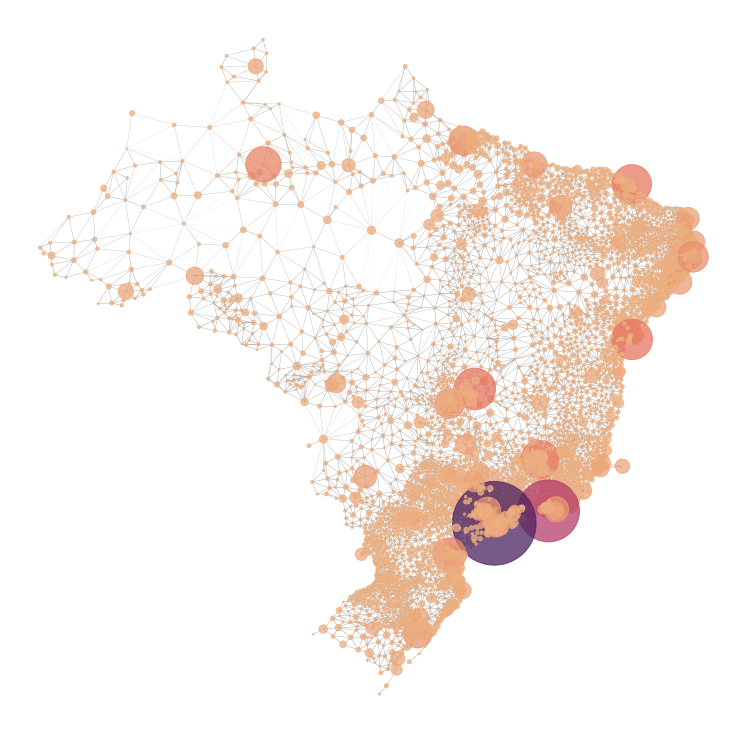

In [15]:
dist = nx.get_edge_attributes(H, 'distance')
dist_list = [v for v in dist.values()]
dist_norm = [1 - (float(i)/max(dist_list)) for i in dist_list]

deg = H.degree()
deg_list = [val for (node, val) in deg]
deg_norm = [1 - (float(i)/max(deg_list)) for i in deg_list]

size = nx.get_node_attributes(H, 'population')
size_list = [v for v in size.values()]
size_norm = [float(i)/max(size_list) for i in size_list]

pos = nx.get_node_attributes(H, 'pos')

plt.rcParams["figure.figsize"] = (10,10)
nx.draw(H, pos,
        node_size = [s*7000 for  s in size_norm],
        node_color=size_norm, cmap=sns.color_palette("flare", as_cmap=True),
        edge_color='gray',
        width=[w*0.5 for  w in dist_norm],
        alpha=0.75)
plt.savefig('grafo_cidades.png', transparent=True)
plt.show()

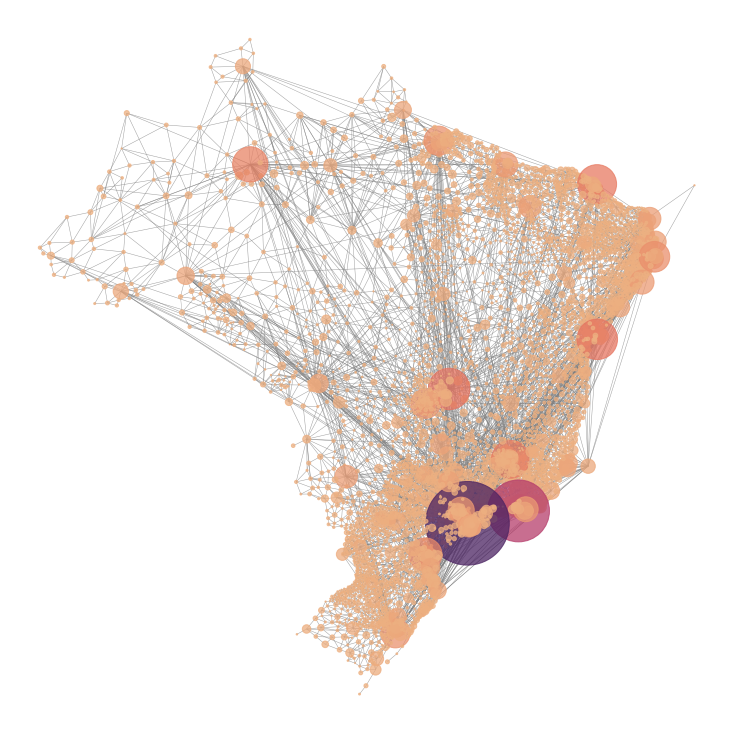

In [16]:
dist = nx.get_edge_attributes(G, 'distance')
dist_list = [v for v in size.values()]
dist_norm = [1 - (float(i)/max(size_list)) for i in size_list]

size = nx.get_node_attributes(G, 'population')
size_list = [v for v in size.values()]
size_norm = [float(i)/max(size_list) for i in size_list]

pos = nx.get_node_attributes(G, 'pos')
plt.rcParams["figure.figsize"] = (10,10)
nx.draw(G, pos,
        node_size = [s*7000 for  s in size_norm],
        node_color=size_norm, cmap=sns.color_palette("flare", as_cmap=True),
        edge_color='gray',
        width=[w*0.5 for  w in dist_norm],
        alpha=0.75)
plt.savefig('grafo_cidades_aeroportos.png', transparent=True)
plt.show()